In [9]:
#
#
#
import arslabrobotics as ar
import numpy as np
import random
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

data = np.loadtxt("cart_data.txt")
(rows, _) = data.shape

ORDER = 1
arx = ar.identification.NeuralARX(data, ORDER, 0)
IN, OUT = arx.prepare()
rows -= ORDER
print(IN.shape, rows)

model = Sequential( [
    Input(shape = (ORDER+1,)),
    Dense(10, activation='relu'),
    Dense(1, activation='relu')
    ]
)

adam_optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=adam_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

max_in = np.max(IN)
max_out = np.max(OUT)
print(max_in, max_out)
IN = IN / max_in
OUT = OUT / max_out

test_size = int(rows / 20)
mask_values = random.sample(range(0, rows), test_size)

train_mask = np.ones(rows, dtype=bool)
train_mask[mask_values] = False

test_mask = np.zeros(rows, dtype=bool)
test_mask[mask_values] = True

in_train = IN[train_mask]
out_train = OUT[train_mask]

print(in_train.shape)

in_test = IN[test_mask]
out_test = OUT[test_mask]

history = model.fit(
    in_train,
    out_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)




(2000, 2, 1) 2000
555.5555477564618 555.5555478266535
(1900, 2, 1)
Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0000e+00 - loss: 14.9841 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 14.9841 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 14.9841 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 14.9841 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 14.9841 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 14.9841 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 14.9841 - val_accuracy: 0.00

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


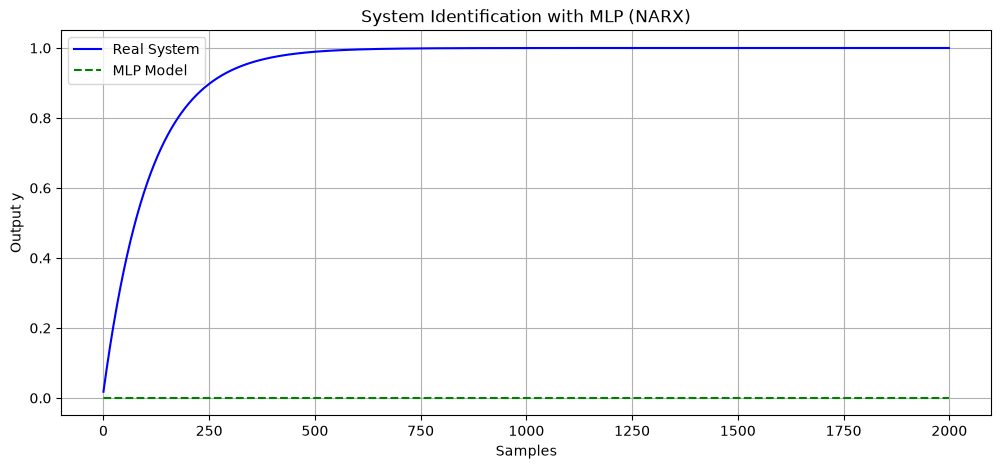

In [10]:

y_pred = model.predict(IN)

plt.figure(figsize=(12, 5))
plt.plot(OUT, label='Real System', color='blue')
plt.plot(y_pred, label='MLP Model', linestyle='--', color='green')
plt.title('System Identification with MLP (NARX)')
plt.xlabel('Samples')
plt.ylabel('Output y')
plt.legend()
plt.grid(True)
plt.show()